### Avance 2 – Semanas 8 a 11  
## Caso 1: ¿Qué hace que un producto triunfe en e-commerce?

Este notebook continúa el trabajo de la PC1.  
La PC1 ya contenía el EDA inicial: distribución de calificaciones, top categorías, tiempo de entrega, costo de envío y entregas a tiempo vs. retrasos.

En este Avance 2 se trabaja lo que corresponde hasta la semana 11:

- análisis profundo de variables clave;
- validación de hipótesis;
- correlaciones y segmentación;
- modelo básico con K-Means;
- tablas listas para dashboard.

## 1. Carga de datos

Se utiliza el dataset Brazilian E-Commerce Public Dataset by Olist desde Kaggle.  
El objetivo es construir una base consolidada a nivel de pedido para analizar satisfacción del cliente.

In [ ]:
# Si estás en Colab y no tienes kagglehub instalado, descomenta esta línea:
# !pip install kagglehub

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

orders = pd.read_csv(f"{path}/olist_orders_dataset.csv")
order_items = pd.read_csv(f"{path}/olist_order_items_dataset.csv")
products = pd.read_csv(f"{path}/olist_products_dataset.csv")
reviews = pd.read_csv(f"{path}/olist_order_reviews_dataset.csv")
customers = pd.read_csv(f"{path}/olist_customers_dataset.csv")
sellers = pd.read_csv(f"{path}/olist_sellers_dataset.csv")

# Traducción de categorías, si está disponible en el dataset
try:
    translation = pd.read_csv(f"{path}/product_category_name_translation.csv")
except:
    translation = None

print("orders:", orders.shape)
print("order_items:", order_items.shape)
print("products:", products.shape)
print("reviews:", reviews.shape)
print("customers:", customers.shape)
print("sellers:", sellers.shape)

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
orders: (99441, 8)
order_items: (112650, 7)
products: (32951, 9)
reviews: (99224, 7)
customers: (99441, 5)
sellers: (3095, 4)


## 2. Preparación e integración de datos

En esta parte se unen las tablas principales y se crean variables nuevas para el análisis:

- `delivery_time_days`: días reales de entrega.
- `delay_days`: días de retraso frente a la fecha estimada.
- `is_late`: identifica si el pedido llegó tarde.
- `total_price`: precio total del pedido.
- `total_freight`: costo total de envío.
- `freight_ratio`: costo de envío dividido entre precio del producto.
- `low_satisfaction`: calificación baja, de 1 a 3.

In [ ]:
# Filtrar pedidos entregados
orders_clean = orders[orders["order_status"] == "delivered"].copy()

# Convertir fechas
date_cols = [
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    orders_clean[col] = pd.to_datetime(orders_clean[col], errors="coerce")

orders_clean = orders_clean.dropna(subset=["order_delivered_customer_date"])

# Variables logísticas
orders_clean["delivery_time_days"] = (
    orders_clean["order_delivered_customer_date"] - orders_clean["order_purchase_timestamp"]
).dt.days

orders_clean["delay_days"] = (
    orders_clean["order_delivered_customer_date"] - orders_clean["order_estimated_delivery_date"]
).dt.days

orders_clean["is_late"] = orders_clean["delay_days"] > 0
orders_clean["on_time_status"] = np.where(orders_clean["is_late"], "Retrasado", "A tiempo")

# Variables de fecha
orders_clean["purchase_month"] = orders_clean["order_purchase_timestamp"].dt.to_period("M").astype(str)
orders_clean["purchase_year"] = orders_clean["order_purchase_timestamp"].dt.year

# Agregar items a nivel pedido
items_agg = order_items.groupby("order_id").agg(
    total_price=("price", "sum"),
    total_freight=("freight_value", "sum"),
    num_items=("order_item_id", "max"),
    product_id=("product_id", "first"),
    seller_id=("seller_id", "first")
).reset_index()

# Unir productos
items_products = items_agg.merge(products, on="product_id", how="left")

if translation is not None:
    items_products = items_products.merge(translation, on="product_category_name", how="left")
    items_products["category"] = items_products["product_category_name_english"].fillna(
        items_products["product_category_name"]
    )
else:
    items_products["category"] = items_products["product_category_name"]

# Reviews a nivel pedido
reviews_agg = reviews.groupby("order_id").agg(
    review_score=("review_score", "mean")
).reset_index()

# Dataset final
df = orders_clean.merge(items_products, on="order_id", how="left")
df = df.merge(reviews_agg, on="order_id", how="left")
df = df.merge(customers[["customer_id", "customer_state", "customer_city"]], on="customer_id", how="left")

# Variables de negocio
df["freight_ratio"] = df["total_freight"] / df["total_price"].replace(0, np.nan)
df["low_satisfaction"] = df["review_score"] <= 3

# Limpieza básica
df = df[
    (df["delivery_time_days"] >= 0) &
    (df["total_price"] > 0) &
    (df["total_freight"] >= 0) &
    (df["review_score"].notna())
].copy()

print("Base consolidada:", df.shape)
df.head()

Base consolidada: (95824, 34)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time_days,delay_days,is_late,on_time_status,purchase_month,purchase_year,total_price,total_freight,num_items,product_id,seller_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,category,review_score,customer_state,customer_city,freight_ratio,low_satisfaction
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8,-8,False,A tiempo,2017-10,2017,29.99,8.72,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,utilidades_domesticas,40.00,268.00,4.00,500.00,19.00,8.00,13.00,housewares,housewares,4.00,SP,sao paulo,0.29,False
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13,-6,False,A tiempo,2018-07,2018,118.70,22.76,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,perfumaria,29.00,178.00,1.00,400.00,19.00,13.00,19.00,perfumery,perfumery,4.00,BA,barreiras,0.19,False
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9,-18,False,A tiempo,2018-08,2018,159.90,19.22,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,automotivo,46.00,232.00,1.00,420.00,24.00,19.00,21.00,auto,auto,5.00,GO,vianopolis,0.12,False
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13,-13,False,A tiempo,2017-11,2017,45.00,27.20,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,pet_shop,59.00,468.00,3.00,450.00,30.00,10.00,20.00,pet_shop,pet_shop,5.00,RN,sao goncalo do amarante,0.60,False
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2,-10,False,A tiempo,2018-02,2018,19.90,8.72,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,papelaria,38.00,316.00,4.00,250.00,51.00,15.00,15.00,stationery,stationery,5.00,SP,santo andre,0.44,False


# Semana 8 – Análisis profundo de variables clave

En esta semana se profundizan las variables que pueden explicar la satisfacción del cliente.

## 3.1 Entrega a tiempo vs. satisfacción

**Pregunta de negocio:**  
¿Los pedidos retrasados reciben peores calificaciones que los pedidos entregados a tiempo?

In [ ]:
late_summary = df.groupby("on_time_status").agg(
    pedidos=("order_id", "nunique"),
    calificacion_promedio=("review_score", "mean"),
    porcentaje_baja_satisfaccion=("low_satisfaction", "mean"),
    tiempo_entrega_promedio=("delivery_time_days", "mean"),
    retraso_promedio=("delay_days", "mean")
).reset_index()

late_summary["porcentaje_baja_satisfaccion"] *= 100
late_summary

,on_time_status,pedidos,calificacion_promedio,porcentaje_baja_satisfaccion,tiempo_entrega_promedio,retraso_promedio
0,A tiempo,89443,4.29,17.34,10.53,-13.51
1,Retrasado,6381,2.27,73.25,33.36,10.52


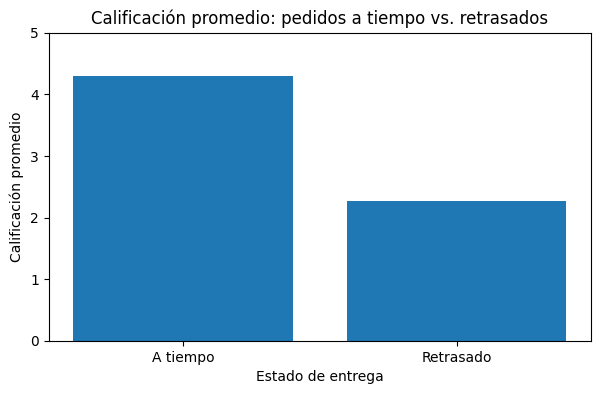

In [ ]:
plt.figure(figsize=(7,4))
plt.bar(late_summary["on_time_status"], late_summary["calificacion_promedio"])
plt.title("Calificación promedio: pedidos a tiempo vs. retrasados")
plt.xlabel("Estado de entrega")
plt.ylabel("Calificación promedio")
plt.ylim(0,5)
plt.show()

Los pedidos entregados a tiempo presentan una calificación promedio de 4.29, mientras que los pedidos retrasados tienen una calificación promedio de 2.27. Además, el porcentaje de baja satisfacción aumenta de 17.34% en pedidos a tiempo a 73.25% en pedidos retrasados. Esto muestra que el cumplimiento de la promesa de entrega es uno de los factores más importantes para la satisfacción del cliente.

## 3.2 Costo de envío relativo y satisfacción

**Pregunta de negocio:**  
¿La satisfacción disminuye cuando el envío representa una parte alta del precio?

In [ ]:
df["freight_ratio_group"] = pd.qcut(
    df["freight_ratio"].replace([np.inf, -np.inf], np.nan),
    q=4,
    labels=["Muy bajo", "Bajo", "Alto", "Muy alto"],
    duplicates="drop"
)

freight_summary = df.groupby("freight_ratio_group", observed=True).agg(
    pedidos=("order_id", "nunique"),
    freight_ratio_promedio=("freight_ratio", "mean"),
    envio_promedio=("total_freight", "mean"),
    precio_promedio=("total_price", "mean"),
    calificacion_promedio=("review_score", "mean"),
    porcentaje_baja_satisfaccion=("low_satisfaction", "mean")
).reset_index()

freight_summary["porcentaje_baja_satisfaccion"] *= 100
freight_summary

,freight_ratio_group,pedidos,freight_ratio_promedio,envio_promedio,precio_promedio,calificacion_promedio,porcentaje_baja_satisfaccion
0,Muy bajo,23957,0.08,19.93,296.31,4.20,19.64
1,Bajo,23965,0.18,21.25,123.30,4.16,20.65
2,Alto,23948,0.29,23.78,82.85,4.14,21.43
3,Muy alto,23954,0.68,26.09,44.71,4.11,22.52


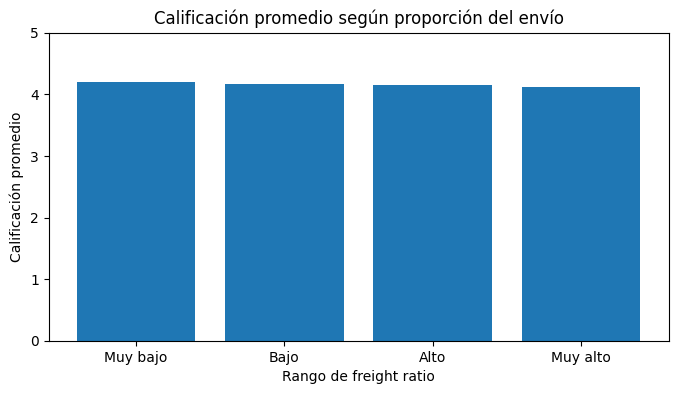

In [ ]:
plt.figure(figsize=(8,4))
plt.bar(freight_summary["freight_ratio_group"].astype(str), freight_summary["calificacion_promedio"])
plt.title("Calificación promedio según proporción del envío")
plt.xlabel("Rango de freight ratio")
plt.ylabel("Calificación promedio")
plt.ylim(0,5)
plt.show()

La calificación promedio disminuye ligeramente conforme aumenta el peso relativo del costo de envío. Sin embargo, la diferencia entre grupos no es tan fuerte como en el caso del retraso. Esto sugiere que el costo de envío puede afectar la percepción del cliente, pero su impacto parece menor frente al cumplimiento de la entrega.

## 3.3 Categorías y satisfacción

**Pregunta de negocio:**  
¿Qué categorías presentan mejor o peor satisfacción?

In [ ]:
category_summary = df.groupby("category").agg(
    pedidos=("order_id", "nunique"),
    calificacion_promedio=("review_score", "mean"),
    porcentaje_baja_satisfaccion=("low_satisfaction", "mean"),
    tiempo_entrega_promedio=("delivery_time_days", "mean"),
    retraso_promedio=("delay_days", "mean"),
    envio_promedio=("total_freight", "mean"),
    precio_promedio=("total_price", "mean")
).reset_index()

category_summary["porcentaje_baja_satisfaccion"] *= 100

# Filtrar categorías con cantidad suficiente de pedidos
category_summary_valid = category_summary[category_summary["pedidos"] >= 300].copy()

top_categories_score = category_summary_valid.sort_values("calificacion_promedio", ascending=False).head(10)
bottom_categories_score = category_summary_valid.sort_values("calificacion_promedio", ascending=True).head(10)

bottom_categories_score

,category,pedidos,calificacion_promedio,porcentaje_baja_satisfaccion,tiempo_entrega_promedio,retraso_promedio,envio_promedio,precio_promedio
57,office_furniture,1236,3.65,36.25,20.17,-11.77,53.42,213.97
4,audio,341,3.85,31.09,13.03,-10.03,16.37,149.32
47,home_confort,368,3.91,31.52,13.09,-9.86,23.74,156.94
7,bed_bath_table,9072,4.01,25.65,12.51,-11.39,21.98,111.58
48,home_construction,464,4.05,23.06,13.08,-11.18,28.67,173.99
70,telephony,4052,4.06,24.04,12.48,-11.24,17.01,76.03
39,furniture_decor,6167,4.07,23.79,12.58,-12.32,27.04,115.08
15,computers_accessories,6469,4.08,22.71,12.70,-12.39,22.09,136.51
40,furniture_living_room,404,4.09,23.51,13.37,-11.77,43.57,165.02
6,baby,2741,4.12,22.36,12.18,-11.52,24.03,144.73


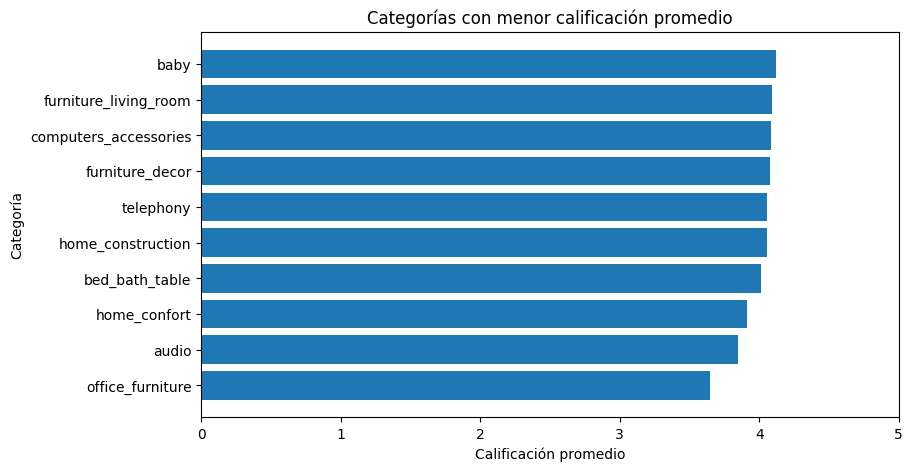

In [ ]:
plt.figure(figsize=(9,5))
ordered = bottom_categories_score.sort_values("calificacion_promedio")
plt.barh(ordered["category"], ordered["calificacion_promedio"])
plt.title("Categorías con menor calificación promedio")
plt.xlabel("Calificación promedio")
plt.ylabel("Categoría")
plt.xlim(0,5)
plt.show()

Las categorías con menor calificación promedio podrían requerir un análisis específico, ya que pueden estar asociadas a productos más difíciles de transportar, expectativas más altas del cliente o mayor probabilidad de problemas logísticos.

## 3.4 Integración de fuente externa: Feriados en Brasil

**Integración de fuente externa: Feriados en Brasil**  


In [ ]:
!pip install holidays
import holidays

br_holidays = holidays.Brazil()

df["order_date"] = pd.to_datetime(df["order_purchase_timestamp"]).dt.date
df["is_holiday"] = df["order_date"].isin(br_holidays).astype(int)

df["is_weekend"] = pd.to_datetime(df["order_purchase_timestamp"]).dt.weekday >= 5

df["is_holiday_or_weekend"] = (
    df["is_holiday"] | df["is_weekend"]
).astype(int)

In [ ]:

df.groupby("is_holiday_or_weekend")["order_id"].count()

,order_id
is_holiday_or_weekend,
0,73786
1,22038


In [ ]:
df.groupby("is_holiday_or_weekend")["delay_days"].mean()


,delay_days
is_holiday_or_weekend,
0,-11.75
1,-12.46


In [ ]:
df.groupby("is_holiday_or_weekend")["review_score"].mean()

,review_score
is_holiday_or_weekend,
0,4.16
1,4.15


<Axes: xlabel='is_holiday_or_weekend'>

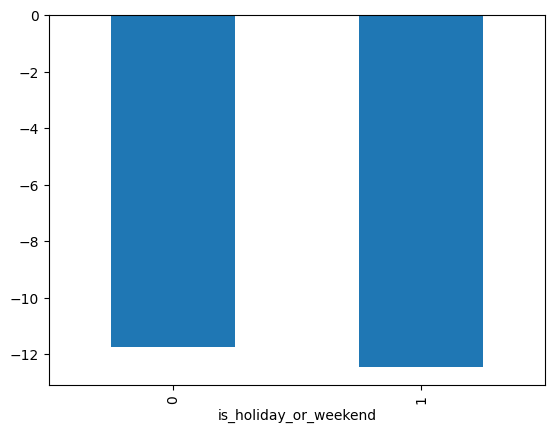

In [ ]:
df.groupby("is_holiday_or_weekend")["delay_days"].mean().plot(kind="bar")

<Axes: xlabel='is_holiday_or_weekend'>

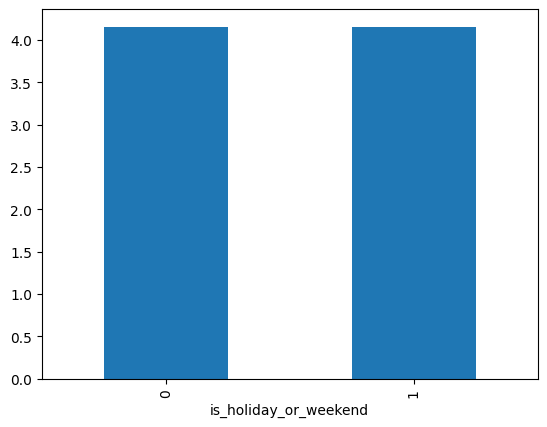

In [ ]:
df.groupby("is_holiday_or_weekend")["review_score"].mean().plot(kind="bar")

El análisis muestra que los feriados y fines de semana no tienen un impacto significativo en el desempeño logístico ni en la satisfacción del cliente.

En términos de tiempos de entrega, los pedidos realizados en estos días presentan incluso un ligero adelanto promedio (-12.46 días vs -11.75), lo que sugiere que la operación logística mantiene su eficiencia independientemente del calendario.

Asimismo, la calificación promedio de los clientes se mantiene prácticamente constante (4.15 vs 4.16), indicando que la experiencia del usuario no se ve afectada por la ocurrencia de feriados.

En conjunto, estos resultados sugieren que la empresa ha logrado una operación robusta y estable frente a variaciones temporales como feriados y fines de semana.

Sin embargo, la baja variación observada también podría indicar que el efecto de los feriados es marginal frente a otros factores más determinantes como la distancia de entrega o la carga logística.

# Variable externa: feriados pueden afectar la logística y tiempos de entrega

## 3.5 Precio y calificación

**Pregunta de negocio:**  
¿El precio del producto tiene relación con la calificación del cliente?

In [ ]:
df["price_group"] = pd.qcut(
    df["total_price"],
    q=4,
    labels=["Precio bajo", "Precio medio-bajo", "Precio medio-alto", "Precio alto"],
    duplicates="drop"
)

price_summary = df.groupby("price_group", observed=True).agg(
    pedidos=("order_id", "nunique"),
    precio_promedio=("total_price", "mean"),
    envio_promedio=("total_freight", "mean"),
    calificacion_promedio=("review_score", "mean"),
    porcentaje_baja_satisfaccion=("low_satisfaction", "mean")
).reset_index()

price_summary["porcentaje_baja_satisfaccion"] *= 100
price_summary

,price_group,pedidos,precio_promedio,envio_promedio,calificacion_promedio,porcentaje_baja_satisfaccion
0,Precio bajo,24101,28.59,15.22,4.22,19.56
1,Precio medio-bajo,23815,63.78,18.05,4.18,20.31
2,Precio medio-alto,24207,114.88,22.83,4.16,20.95
3,Precio alto,23701,342.59,35.10,4.07,23.46


La calificación promedio disminuye ligeramente conforme aumenta el precio del producto. Sin embargo, la correlación directa entre `total_price` y `review_score` es muy baja, por lo que el precio **no explica de forma relevante** la satisfacción cuando se compara con el tiempo de entrega y el retraso.

Por ello, la hipótesis se interpreta como una **relación débil/no determinante**: el precio puede aportar contexto a la experiencia de compra, pero no debe ser la palanca principal de mejora.


In [ ]:
corr_vars = [
    "review_score",
    "total_price",
    "total_freight",
    "freight_ratio",
    "delivery_time_days",
    "delay_days",
    "num_items"
]

corr_matrix = df[corr_vars].corr(numeric_only=True)
corr_matrix

,review_score,total_price,total_freight,freight_ratio,delivery_time_days,delay_days,num_items
review_score,1.00,-0.03,-0.09,-0.02,-0.33,-0.27,-0.12
total_price,-0.03,1.00,0.41,-0.30,0.06,-0.01,0.15
total_freight,-0.09,0.41,1.00,0.10,0.17,-0.05,0.44
freight_ratio,-0.02,-0.30,0.10,1.00,0.08,-0.03,0.07
delivery_time_days,-0.33,0.06,0.17,0.08,1.00,0.60,-0.02
delay_days,-0.27,-0.01,-0.05,-0.03,0.60,1.00,-0.03
num_items,-0.12,0.15,0.44,0.07,-0.02,-0.03,1.00


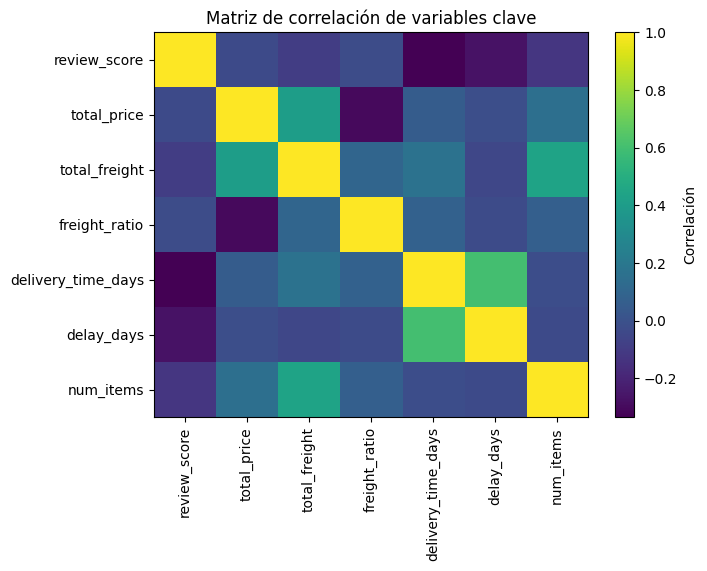

In [ ]:
plt.figure(figsize=(7,5))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="Correlación")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.title("Matriz de correlación de variables clave")
plt.show()

# Semana 8: Análisis profundo de otras variables clave

Análisis de Freight Ratio por nivel de satisfacción:
                     count  mean  std  min  25%  50%  75%   max
low_satisfaction                                               
False            75,643.00  0.30 0.31 0.00 0.13 0.22 0.38 21.45
True             20,181.00  0.32 0.31 0.00 0.14 0.24 0.40  5.96


/tmp/ipykernel_12216/1708880546.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


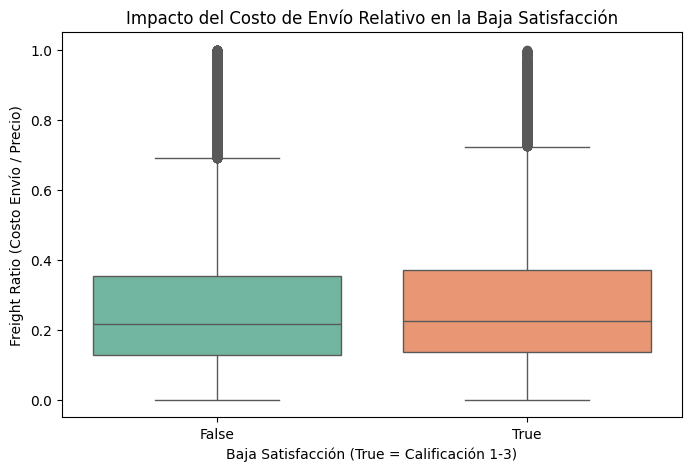

In [ ]:
# Análisis de la relación entre el Freight Ratio (Costo de envío / Precio) y la Satisfacción
import seaborn as sns

print("Análisis de Freight Ratio por nivel de satisfacción:")
print(df.groupby("low_satisfaction")["freight_ratio"].describe())

# Gráfico para ver la distribución del freight ratio según la satisfacción
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df[df["freight_ratio"] < 1],
    x="low_satisfaction",
    y="freight_ratio",
    palette="Set2",
)
plt.title("Impacto del Costo de Envío Relativo en la Baja Satisfacción")
plt.xlabel("Baja Satisfacción (True = Calificación 1-3)")
plt.ylabel("Freight Ratio (Costo Envío / Precio)")
plt.show()

# Semana 9 – Validación de hipótesis

Se retoman las hipótesis de la PC1 y se evalúan con evidencia numérica.

In [ ]:
hypothesis_results = []


def add_hypothesis(hipotesis, estado, evidencia, insight):
    hypothesis_results.append(
        {
            "Hipótesis": hipotesis,
            "Estado": estado,
            "Evidencia": evidencia,
            "Insight de negocio": insight,
        }
    )


# H1: retraso vs calificación
score_on_time = late_summary.loc[
    late_summary["on_time_status"] == "A tiempo", "calificacion_promedio"
].values
score_late = late_summary.loc[
    late_summary["on_time_status"] == "Retrasado", "calificacion_promedio"
].values

if len(score_on_time) > 0 and len(score_late) > 0:
    diff_h1 = float(score_on_time[0] - score_late[0])
    estado_h1 = "Validada" if diff_h1 > 0 else "Rechazada o no concluyente"
    evidencia_h1 = (
        f"Los pedidos a tiempo tienen {diff_h1:.2f} puntos más de calificación "
        "promedio que los retrasados."
    )
else:
    estado_h1 = "No concluyente"
    evidencia_h1 = "No se pudo comparar ambos grupos."

add_hypothesis(
    "H1: Los pedidos con mayor tiempo de entrega reciben calificaciones más bajas.",
    estado_h1,
    evidencia_h1,
    "El cumplimiento de la entrega es clave para proteger la satisfacción del cliente.",
)

# H2: freight ratio
freight_corr = corr_matrix.loc["freight_ratio", "review_score"]
if len(freight_summary) >= 2:
    low_score = freight_summary.iloc[0]["calificacion_promedio"]
    high_score = freight_summary.iloc[-1]["calificacion_promedio"]
    diff_h2 = float(low_score - high_score)
    evidencia_h2 = (
        f"Correlación freight_ratio-review_score: {freight_corr:.2f}; "
        f"diferencia descriptiva entre extremos: {diff_h2:.2f} puntos."
    )
    estado_h2 = (
        "Relación débil / no determinante"
        if abs(freight_corr) < 0.05
        else "Validada parcialmente"
    )
else:
    estado_h2 = "No concluyente"
    evidencia_h2 = "No se pudieron formar grupos suficientes de freight ratio."

add_hypothesis(
    "H2: Los costos de envío elevados reducen la satisfacción del cliente.",
    estado_h2,
    evidencia_h2,
    "El freight ratio no es un determinante principal frente al retraso logístico.",
)

# H3: categoría
if len(category_summary_valid) > 0:
    best_cat = category_summary_valid.sort_values(
        "calificacion_promedio", ascending=False
    ).iloc[0]
    worst_cat = category_summary_valid.sort_values(
        "calificacion_promedio", ascending=True
    ).iloc[0]
    diff_h3 = float(
        best_cat["calificacion_promedio"] - worst_cat["calificacion_promedio"]
    )
    estado_h3 = "Validada" if diff_h3 >= 0.2 else "Parcialmente validada"
    evidencia_h3 = (
        f"La mejor categoría fue {best_cat['category']} y la peor fue "
        f"{worst_cat['category']}; la diferencia fue de {diff_h3:.2f} puntos."
    )
else:
    estado_h3 = "No concluyente"
    evidencia_h3 = "No hubo categorías con suficientes pedidos para una comparación sólida."

add_hypothesis(
    "H3: Existen categorías de productos que obtienen mejores calificaciones que otras.",
    estado_h3,
    evidencia_h3,
    "La estrategia debe diferenciarse por categoría y no aplicarse igual a todo el marketplace.",
)

# H4: precio
price_corr = corr_matrix.loc["total_price", "review_score"]
estado_h4 = (
    "Relación débil / no determinante"
    if abs(price_corr) < 0.05
    else "Validada parcialmente"
)
evidencia_h4 = f"La correlación entre precio y calificación fue {price_corr:.3f}."

add_hypothesis(
    "H4: El precio del producto influye en la calificación del cliente.",
    estado_h4,
    evidencia_h4,
    "El precio no explica de forma relevante la satisfacción frente a las variables logísticas.",
)

hypothesis_df = pd.DataFrame(hypothesis_results)
display(hypothesis_df)


,Hipótesis,Estado,Evidencia,Insight de negocio
0,H1: Los pedidos con mayor tiempo de entrega re...,Validada,Los pedidos a tiempo tienen 2.02 puntos más de...,El cumplimiento de la entrega es clave para pr...
1,H2: Los costos de envío elevados reducen la sa...,Relación débil / no determinante,Correlación freight_ratio-review_score: -0.02;...,El freight ratio no es un determinante princip...
2,H3: Existen categorías de productos que obtien...,Validada,La mejor categoría fue books_general_interest ...,La estrategia debe diferenciarse por categoría...
3,H4: El precio del producto influye en la calif...,Relación débil / no determinante,La correlación entre precio y calificación fue...,El precio no explica de forma relevante la sat...


# Semana 10 – Modelado básico

Se aplica K-Means para segmentar pedidos según comportamiento logístico, precio, envío y satisfacción.

**Pregunta de negocio:**  
¿Qué grupos de pedidos presentan mayor riesgo de baja satisfacción?

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

print("Preparando los datos para K-Means...")

# Preparación inicial. El número final de clusters se selecciona
# en la siguiente sección con silhouette score; aquí no se fija k=3.
features_to_cluster = ["total_price", "delivery_time_days", "review_score"]

df_clustering = df.dropna(subset=features_to_cluster).copy()

scaler_initial = StandardScaler()
X_scaled_initial = scaler_initial.fit_transform(df_clustering[features_to_cluster])

print(
    "Datos preparados para clustering. "
    f"Muestras disponibles: {len(df_clustering):,}"
)


Preparando los datos para K-Means...
Datos preparados para clustering. Muestras disponibles: 95,824


In [ ]:
model_cols = [
    "total_price",
    "total_freight",
    "freight_ratio",
    "delivery_time_days",
    "delay_days",
    "num_items"
]

model_df = df[model_cols + ["review_score", "low_satisfaction", "order_id"]].replace(
    [np.inf, -np.inf], np.nan
).dropna().copy()

# Recortar extremos para evitar distorsiones
for col in model_cols:
    low = model_df[col].quantile(0.01)
    high = model_df[col].quantile(0.99)
    model_df[col] = model_df[col].clip(low, high)

X = model_df[model_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

from sklearn.utils import resample

# Tomar una muestra para acelerar
X_sample = resample(X_scaled, n_samples=10000, random_state=42)

scores = []
for k in range(2, 7):
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_temp = kmeans_temp.fit_predict(X_sample)
    score = silhouette_score(X_sample, labels_temp)
    scores.append({"k": k, "silhouette_score": score})

scores_df = pd.DataFrame(scores)
scores_df

,k,silhouette_score
0,2,0.44
1,3,0.35
2,4,0.37
3,5,0.35
4,6,0.23


Según el silhouette score, el mejor número de clusters es 2, ya que obtiene el valor más alto (0.44). Esto indica que los pedidos pueden dividirse en dos segmentos principales con diferencias moderadas entre sí.

In [ ]:
best_k = int(scores_df.sort_values("silhouette_score", ascending=False).iloc[0]["k"])

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
model_df["cluster"] = kmeans.fit_predict(X_scaled)

cluster_summary = model_df.groupby("cluster").agg(
    pedidos=("order_id", "nunique"),
    precio_promedio=("total_price", "mean"),
    envio_promedio=("total_freight", "mean"),
    freight_ratio_promedio=("freight_ratio", "mean"),
    tiempo_entrega_promedio=("delivery_time_days", "mean"),
    retraso_promedio=("delay_days", "mean"),
    calificacion_promedio=("review_score", "mean"),
    porcentaje_baja_satisfaccion=("low_satisfaction", "mean")
).reset_index()

cluster_summary["porcentaje_baja_satisfaccion"] *= 100
cluster_summary = cluster_summary.sort_values("porcentaje_baja_satisfaccion", ascending=False)

print("Mejor k según silhouette score:", best_k)
cluster_summary

Mejor k según silhouette score: 2


,cluster,pedidos,precio_promedio,envio_promedio,freight_ratio_promedio,tiempo_entrega_promedio,retraso_promedio,calificacion_promedio,porcentaje_baja_satisfaccion
1,1,14043,317.57,48.62,0.30,13.06,-13.02,3.79,31.55
0,0,81781,98.96,17.70,0.30,11.69,-11.83,4.22,19.26


El cluster 1 concentra pedidos de mayor precio promedio y mayor costo de envío. Este grupo tiene una calificación promedio menor (3.79) y un porcentaje más alto de baja satisfacción (31.55%).

En cambio, el cluster 0 agrupa la mayoría de pedidos, con menor precio y menor costo de envío. Este segmento presenta mejor calificación promedio (4.22) y menor baja satisfacción (19.26%).

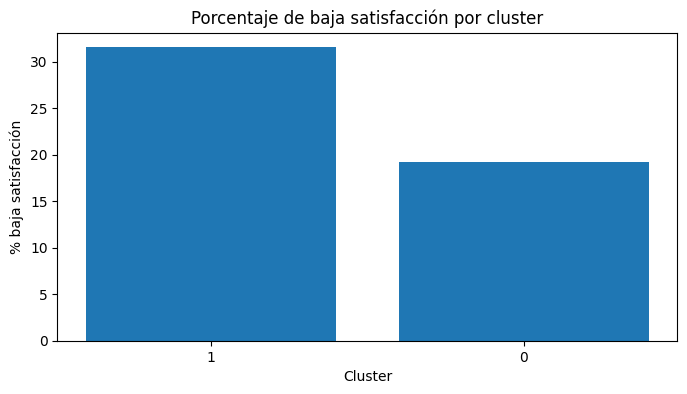

In [ ]:
plt.figure(figsize=(8,4))
plt.bar(cluster_summary["cluster"].astype(str), cluster_summary["porcentaje_baja_satisfaccion"])
plt.title("Porcentaje de baja satisfacción por cluster")
plt.xlabel("Cluster")
plt.ylabel("% baja satisfacción")
plt.show()

El gráfico muestra que el cluster 1 es el segmento con mayor riesgo de baja satisfacción, mientras que el cluster 0 tiene un mejor desempeño. Esto permite identificar qué tipo de pedidos deberían priorizarse para mejorar la experiencia del cliente.

# Semana 11 – Avance del dashboard

Se exportan las tablas que se usarán en Power BI, Looker Studio o Tableau.  
Cada visualización debe responder una pregunta de negocio explícita.

In [ ]:
df["price_group"] = pd.qcut(
    df["total_price"],
    q=4,
    labels=["Precio bajo", "Precio medio-bajo", "Precio medio-alto", "Precio alto"],
    duplicates="drop"
)

dashboard_df = df[[
    "order_id",
    "purchase_month",
    "purchase_year",
    "customer_state",
    "customer_city",
    "category",
    "review_score",
    "low_satisfaction",
    "total_price",
    "total_freight",
    "freight_ratio",
    "freight_ratio_group",
    "price_group",
    "delivery_time_days",
    "delay_days",
    "is_late",
    "on_time_status",
    "num_items"
]].copy()

dashboard_df = dashboard_df.merge(
    model_df[["order_id", "cluster"]],
    on="order_id",
    how="left"
)

dashboard_df.to_csv("dashboard_olist_avance2.csv", index=False)
late_summary.to_csv("tabla_entrega_vs_calificacion.csv", index=False)
freight_summary.to_csv("tabla_envio_vs_calificacion.csv", index=False)
category_summary_valid.to_csv("tabla_categoria_vs_calificacion.csv", index=False)
hypothesis_df.to_csv("tabla_validacion_hipotesis.csv", index=False)
cluster_summary.to_csv("tabla_clusters.csv", index=False)

print("Archivos listos para dashboard:")
print("- dashboard_olist_avance2.csv")
print("- tabla_entrega_vs_calificacion.csv")
print("- tabla_envio_vs_calificacion.csv")
print("- tabla_categoria_vs_calificacion.csv")
print("- tabla_validacion_hipotesis.csv")
print("- tabla_clusters.csv")

Archivos listos para dashboard:
- dashboard_olist_avance2.csv
- tabla_entrega_vs_calificacion.csv
- tabla_envio_vs_calificacion.csv
- tabla_categoria_vs_calificacion.csv
- tabla_validacion_hipotesis.csv
- tabla_clusters.csv


## Visualizaciones para el dashboard

| Visualización | Pregunta de negocio | Tabla sugerida |
|---|---|---|
| KPI general | ¿Cuál es el nivel general de satisfacción y retraso? | `dashboard_olist_avance2.csv` |
| Entrega vs. calificación | ¿Cómo afecta el retraso a la satisfacción? | `tabla_entrega_vs_calificacion.csv` |
| Envío vs. calificación | ¿El costo relativo de envío reduce la satisfacción? | `tabla_envio_vs_calificacion.csv` |
| Categorías | ¿Qué categorías presentan mejor o peor desempeño? | `tabla_categoria_vs_calificacion.csv` |
| Clusters | ¿Qué segmentos tienen mayor riesgo de baja satisfacción? | `tabla_clusters.csv` |

### 5 insights principales del análisis

### 1. Impacto crítico de los retrasos logísticos

El cumplimiento del tiempo de entrega es el principal detonante de insatisfacción. Los pedidos entregados **a tiempo** tienen una calificación promedio de **4.29**, mientras que los **retrasados** caen a **2.27**. Además, la baja satisfacción pasa de **17.34%** a **73.25%**, lo que evidencia que el retraso destruye la experiencia del cliente.

### 2. Confirmación estadística: el tiempo pesa más que el dinero

La matriz de correlación confirma que las variables más asociadas negativamente con la satisfacción son el **tiempo de entrega** `delivery_time_days` con **-0.33** y los **días de retraso** `delay_days` con **-0.27**. En cambio, el precio `total_price` tiene solo **-0.03** y el costo de envío relativo `freight_ratio` **-0.02**. Por tanto, la espera afecta mucho más que el factor monetario.

### 3. Alerta operativa en categorías complejas: Office Furniture

Entre las categorías con más de 300 pedidos, **office furniture** es la peor evaluada, con una calificación promedio de **3.65** y una baja satisfacción de **36.25%**. Además, presenta un tiempo de entrega promedio de **20.17 días**, lo que la convierte en una categoría prioritaria para reducir el tiempo total de entrega.

### 4. Segmentación K-Means: dos realidades de Olist

El modelo K-Means, con un mejor **Silhouette Score de 0.44**, divide los pedidos en dos clusters. El **Cluster 0** concentra el **85.3%** de transacciones (**81,781 pedidos**) y representa el mercado masivo, con precio promedio de **98.96** y envío promedio de **17.70**. El **Cluster 1** representa el **14.7%** (**14,043 pedidos**) y agrupa compras de mayor valor, con ticket promedio de **317.57** y envío promedio de **48.62**. A pesar de estas diferencias, ambos clusters mantienen el mismo `freight_ratio` promedio de **0.30**.

### 5. Fricción por costo de envío relativo

El `freight_ratio` tiene un impacto sutil pero visible. Cuando el envío es **muy bajo** y representa solo el **8%** del precio, la calificación promedio es **4.20**, con tickets altos de **296.31**. En cambio, cuando el envío pesa más sobre productos baratos, la calificación baja gradualmente. Esto muestra que la fricción no depende solo del monto del envío, sino de cuánto representa frente al valor del producto.


---
# Semana 12–14 — Cierre
Esta sección usa la fuente externa de **feriados y fines de semana de Brasil** que ya fue integrada en la sección 3.4. Consolida los resultados finales, escenarios, recomendaciones y archivos para el dashboard.


## 4.1 Resultado final de la fuente externa: feriados y fines de semana

La sección 3.4 ya integró la librería `holidays` para Brasil y creó las variables `is_holiday`, `is_weekend` e `is_holiday_or_weekend`. La siguiente tabla consolida el resultado para el informe y el dashboard.


In [ ]:
# Resumen de feriados y fines de semana
calendar_summary = df.groupby("is_holiday_or_weekend").agg(
    pedidos=("order_id", "nunique"),
    retraso_promedio=("delay_days", "mean"),
    calificacion_promedio=("review_score", "mean"),
    porcentaje_baja_satisfaccion=("low_satisfaction", "mean"),
    porcentaje_retraso=("is_late", "mean")
).reset_index()

calendar_summary["periodo"] = calendar_summary["is_holiday_or_weekend"].map(
    {0: "Día regular", 1: "Feriado o fin de semana"}
)
calendar_summary["porcentaje_baja_satisfaccion"] *= 100
calendar_summary["porcentaje_retraso"] *= 100

calendar_summary = calendar_summary[
    [
        "periodo",
        "pedidos",
        "retraso_promedio",
        "calificacion_promedio",
        "porcentaje_baja_satisfaccion",
        "porcentaje_retraso",
    ]
]

display(calendar_summary)


,periodo,pedidos,retraso_promedio,calificacion_promedio,porcentaje_baja_satisfaccion,porcentaje_retraso
0,Día regular,73786,-11.75,4.16,21.02,6.76
1,Feriado o fin de semana,22038,-12.46,4.15,21.19,6.32


## 4.2 Interpretación automática de la fuente externa

La siguiente celda genera una conclusión basada en los resultados reales. Esta comparación es descriptiva: muestra diferencias observadas, pero no prueba causalidad.


In [ ]:
regular = calendar_summary.loc[
    calendar_summary["periodo"] == "Día regular"
].iloc[0]
holiday_weekend = calendar_summary.loc[
    calendar_summary["periodo"] == "Feriado o fin de semana"
].iloc[0]

delay_diff = holiday_weekend["retraso_promedio"] - regular["retraso_promedio"]
score_diff = holiday_weekend["calificacion_promedio"] - regular["calificacion_promedio"]

print("Interpretación automática:")
print(
    f"Los pedidos realizados en feriados o fines de semana tuvieron "
    f"{holiday_weekend['retraso_promedio']:.2f} días de retraso promedio, "
    f"frente a {regular['retraso_promedio']:.2f} en días regulares "
    f"(diferencia: {delay_diff:.2f} días)."
)
print(
    f"La calificación promedio fue {holiday_weekend['calificacion_promedio']:.2f} "
    f"frente a {regular['calificacion_promedio']:.2f} "
    f"(diferencia: {score_diff:.2f} puntos)."
)
print(
    "Conclusión: si las diferencias son cercanas a cero, el calendario no es un "
    "determinante principal frente a los retrasos logísticos."
)


Interpretación automática:
Los pedidos realizados en feriados o fines de semana tuvieron -12.46 días de retraso promedio, frente a -11.75 en días regulares (diferencia: -0.71 días).
La calificación promedio fue 4.15 frente a 4.16 (diferencia: -0.01 puntos).
Conclusión: si las diferencias son cercanas a cero, el calendario no es un determinante principal frente a los retrasos logísticos.


## 4.3 Validación final de hipótesis

Esta tabla corrige las conclusiones que debían quedar alineadas con las correlaciones: H2 (freight ratio) y H4 (precio) se presentan como relaciones débiles/no determinantes.


In [ ]:
# Tabla final de hipótesis para informe, PPT y dashboard
on_time_row = late_summary.loc[
    late_summary["on_time_status"] == "A tiempo"
].iloc[0]
late_row = late_summary.loc[
    late_summary["on_time_status"] == "Retrasado"
].iloc[0]

freight_corr = corr_matrix.loc["freight_ratio", "review_score"]
price_corr = corr_matrix.loc["total_price", "review_score"]

best_cat = category_summary_valid.sort_values(
    "calificacion_promedio", ascending=False
).iloc[0]
worst_cat = category_summary_valid.sort_values(
    "calificacion_promedio", ascending=True
).iloc[0]

hypothesis_df_final = pd.DataFrame([
    {
        "Hipótesis": "H1. Los retrasos reducen la satisfacción.",
        "Estado final": "Validada",
        "Evidencia": (
            f"A tiempo: {on_time_row['calificacion_promedio']:.2f}; "
            f"retrasado: {late_row['calificacion_promedio']:.2f}."
        ),
        "Conclusión": "El retraso logístico es el principal determinante analizado."
    },
    {
        "Hipótesis": "H2. Un freight ratio alto reduce la satisfacción.",
        "Estado final": "Relación débil / no determinante",
        "Evidencia": f"Correlación freight_ratio-review_score: {freight_corr:.2f}.",
        "Conclusión": "No se justifica priorizar subsidios generalizados de envío."
    },
    {
        "Hipótesis": "H3. Existen diferencias de satisfacción entre categorías.",
        "Estado final": "Validada",
        "Evidencia": (
            f"Mejor: {best_cat['category']} ({best_cat['calificacion_promedio']:.2f}); "
            f"peor: {worst_cat['category']} ({worst_cat['calificacion_promedio']:.2f})."
        ),
        "Conclusión": "Las acciones logísticas deben priorizar categorías con menor desempeño."
    },
    {
        "Hipótesis": "H4. El precio influye en la calificación.",
        "Estado final": "Relación débil / no determinante",
        "Evidencia": f"Correlación total_price-review_score: {price_corr:.2f}.",
        "Conclusión": "El precio no explica de forma relevante la satisfacción frente a la logística."
    }
])

display(hypothesis_df_final)


,Hipótesis,Estado final,Evidencia,Conclusión
0,H1. Los retrasos reducen la satisfacción.,Validada,A tiempo: 4.29; retrasado: 2.27.,El retraso logístico es el principal determina...
1,H2. Un freight ratio alto reduce la satisfacción.,Relación débil / no determinante,Correlación freight_ratio-review_score: -0.02.,No se justifica priorizar subsidios generaliza...
2,H3. Existen diferencias de satisfacción entre ...,Validada,Mejor: books_general_interest (4.54); peor: of...,Las acciones logísticas deben priorizar catego...
3,H4. El precio influye en la calificación.,Relación débil / no determinante,Correlación total_price-review_score: -0.03.,El precio no explica de forma relevante la sat...


## 4.4 Verificación del modelo K-Means final

El modelo final es el de la sección anterior que selecciona `best_k` con silhouette score. La preparación inicial ya no fija tres clusters, por lo que solo queda una lógica final de segmentación.


In [ ]:
print("best_k seleccionado:", best_k)
display(scores_df.sort_values("silhouette_score", ascending=False))

if best_k == 2:
    print("Correcto: el modelo final usa 2 clusters, consistente con el PPT e informe.")
else:
    print(
        "Atención: la ejecución seleccionó un k distinto de 2. "
        "Antes de entregar, actualicen informe, PPT y dashboard con el resultado real."
    )


best_k seleccionado: 2


,k,silhouette_score
0,2,0.44
2,4,0.37
3,5,0.35
1,3,0.35
4,6,0.23


Correcto: el modelo final usa 2 clusters, consistente con el PPT e informe.


## 4.5 Escenario 1: reducción de retrasos

**Supuesto:** los pedidos retrasados alcanzan el nivel de baja satisfacción observado en los pedidos entregados a tiempo. Es una estimación de experiencia del cliente; no mide recompra, retención ni causalidad.


In [ ]:
# Escenario 1: reducción de retrasos
n_late = late_row["pedidos"]
current_low_sat_late = late_row["porcentaje_baja_satisfaccion"] / 100
benchmark_low_sat_on_time = on_time_row["porcentaje_baja_satisfaccion"] / 100

potentially_avoided_low_reviews = n_late * (
    current_low_sat_late - benchmark_low_sat_on_time
)

scenario_late = pd.DataFrame([{
    "escenario": "Reducir retrasos al estándar de pedidos a tiempo",
    "pedidos_retrasados": n_late,
    "baja_satisfaccion_actual_pct": current_low_sat_late * 100,
    "baja_satisfaccion_referencia_pct": benchmark_low_sat_on_time * 100,
    "reduccion_estimada_pp": (current_low_sat_late - benchmark_low_sat_on_time) * 100,
    "resenas_bajas_potencialmente_evitables": round(potentially_avoided_low_reviews),
    "calificacion_actual": late_row["calificacion_promedio"],
    "calificacion_referencia": on_time_row["calificacion_promedio"]
}])

display(scenario_late)


,escenario,pedidos_retrasados,baja_satisfaccion_actual_pct,baja_satisfaccion_referencia_pct,reduccion_estimada_pp,resenas_bajas_potencialmente_evitables,calificacion_actual,calificacion_referencia
0,Reducir retrasos al estándar de pedidos a tiempo,6381,73.25,17.34,55.91,3568,2.27,4.29


## 4.6 Escenario 2: despacho prioritario para el cluster de mayor riesgo

**Supuesto:** el cluster con mayor baja satisfacción alcanza el nivel observado en el cluster de menor baja satisfacción. El monto calculado es valor referencial de pedidos potencialmente mejorados; no representa utilidad ni ventas garantizadas.


In [ ]:
# Escenario 2: despacho prioritario para el cluster de mayor riesgo
target_cluster = cluster_summary.sort_values(
    "porcentaje_baja_satisfaccion", ascending=False
).iloc[0]

reference_cluster = cluster_summary.sort_values(
    "porcentaje_baja_satisfaccion", ascending=True
).iloc[0]

target_low_sat = target_cluster["porcentaje_baja_satisfaccion"] / 100
reference_low_sat = reference_cluster["porcentaje_baja_satisfaccion"] / 100

potentially_improved_orders = target_cluster["pedidos"] * (
    target_low_sat - reference_low_sat
)

reference_transaction_value = potentially_improved_orders * target_cluster["precio_promedio"]

scenario_premium = pd.DataFrame([{
    "escenario": "Despacho prioritario para el cluster de mayor riesgo",
    "cluster_objetivo": int(target_cluster["cluster"]),
    "pedidos_cluster_objetivo": target_cluster["pedidos"],
    "precio_promedio_cluster": target_cluster["precio_promedio"],
    "tiempo_entrega_actual": target_cluster["tiempo_entrega_promedio"],
    "tiempo_entrega_referencia": reference_cluster["tiempo_entrega_promedio"],
    "baja_satisfaccion_actual_pct": target_low_sat * 100,
    "baja_satisfaccion_referencia_pct": reference_low_sat * 100,
    "reduccion_estimada_pp": (target_low_sat - reference_low_sat) * 100,
    "pedidos_potencialmente_mejorados": round(potentially_improved_orders),
    "valor_referencial_pedidos_potencialmente_mejorados_brl": round(reference_transaction_value, 2)
}])

display(scenario_premium)


,escenario,cluster_objetivo,pedidos_cluster_objetivo,precio_promedio_cluster,tiempo_entrega_actual,tiempo_entrega_referencia,baja_satisfaccion_actual_pct,baja_satisfaccion_referencia_pct,reduccion_estimada_pp,pedidos_potencialmente_mejorados,valor_referencial_pedidos_potencialmente_mejorados_brl
0,Despacho prioritario para el cluster de mayor ...,1,"14,043.00",317.57,13.06,11.69,31.55,19.26,12.29,1726,"548,283.82"


## 4.7 Recomendaciones trazables

La tabla siguiente relaciona cada recomendación con el hallazgo que la respalda. Se puede usar en el informe y PPT.


In [ ]:
recommendations_df = pd.DataFrame([
    {
        "Recomendación": "Reducir drásticamente los pedidos retrasados",
        "Acción concreta": "Monitoreo de entregas, alertas tempranas, penalizaciones y optimización de rutas.",
        "Hallazgo que la sustenta": "H1: pedidos retrasados presentan menor calificación y mayor baja satisfacción.",
        "Indicador de éxito": "Reducir la tasa de pedidos retrasados y elevar la calificación de pedidos afectados."
    },
    {
        "Recomendación": "Priorizar categorías con menor desempeño logístico",
        "Acción concreta": "Revisar la operación de office furniture y reducir su tiempo total de entrega.",
        "Hallazgo que la sustenta": "H3: office furniture registra calificación baja y mayor tiempo de entrega.",
        "Indicador de éxito": "Reducir el tiempo promedio de entrega y elevar la calificación de la categoría."
    },
    {
        "Recomendación": "Probar despacho prioritario para el cluster de mayor riesgo",
        "Acción concreta": "Piloto de preparación y despacho prioritario para el cluster con mayor baja satisfacción.",
        "Hallazgo que la sustenta": "K-Means: cluster de mayor riesgo combina ticket alto y mayor baja satisfacción.",
        "Indicador de éxito": "Reducir la baja satisfacción del cluster objetivo hacia el nivel de referencia."
    }
])

display(recommendations_df)


,Recomendación,Acción concreta,Hallazgo que la sustenta,Indicador de éxito
0,Reducir drásticamente los pedidos retrasados,"Monitoreo de entregas, alertas tempranas, pena...",H1: pedidos retrasados presentan menor calific...,Reducir la tasa de pedidos retrasados y elevar...
1,Priorizar categorías con menor desempeño logís...,Revisar la operación de office furniture y red...,H3: office furniture registra calificación baj...,Reducir el tiempo promedio de entrega y elevar...
2,Probar despacho prioritario para el cluster de...,Piloto de preparación y despacho prioritario p...,K-Means: cluster de mayor riesgo combina ticke...,Reducir la baja satisfacción del cluster objet...


## 4.8 Exportación final para dashboard

La siguiente celda guarda las tablas finales que deben alimentar el dashboard y respaldar el informe y el PPT.


In [ ]:
# Exportación final para Looker Studio / Power BI
import os
os.makedirs("outputs", exist_ok=True)

calendar_cols = [
    "order_id", "order_date", "is_holiday", "is_weekend", "is_holiday_or_weekend"
]

dashboard_df_final = dashboard_df.merge(
    df[calendar_cols].drop_duplicates("order_id"),
    on="order_id",
    how="left"
)

dashboard_df_final.to_csv("outputs/dashboard_olist_pc2_final.csv", index=False)
calendar_summary.to_csv("outputs/tabla_feriados_fines_semana.csv", index=False)
hypothesis_df_final.to_csv("outputs/tabla_validacion_hipotesis_final.csv", index=False)
scenario_late.to_csv("outputs/tabla_escenario_retrasos.csv", index=False)
scenario_premium.to_csv("outputs/tabla_escenario_cluster.csv", index=False)
cluster_summary.to_csv("outputs/tabla_clusters_final.csv", index=False)
recommendations_df.to_csv("outputs/tabla_recomendaciones.csv", index=False)

print("Archivos exportados en outputs/:")
for file_name in sorted(os.listdir("outputs")):
    print("-", file_name)


Archivos exportados en outputs/:
- dashboard_olist_pc2_final.csv
- tabla_clusters_final.csv
- tabla_escenario_cluster.csv
- tabla_escenario_retrasos.csv
- tabla_feriados_fines_semana.csv
- tabla_recomendaciones.csv
- tabla_validacion_hipotesis_final.csv


## 4.9 Links de entrega


In [1]:
GITHUB_REPO_URL = "https://github.com/nataliaccusiaucas/entrega-pc2"
NOTEBOOK_URL = "https://github.com/nataliaccusiaucas/pc2.final/blob/main/PC2_final.ipynb"
DASHBOARD_URL = "https://datastudio.google.com/reporting/f75a30f8-73c1-45be-8f0b-a3a5e19fc07d/page/mj30F"

print("Repositorio GitHub:", GITHUB_REPO_URL)
print("Notebook:", NOTEBOOK_URL)
print("Dashboard:", DASHBOARD_URL)


Repositorio GitHub: https://github.com/nataliaccusiaucas/entrega-pc2
Notebook: https://github.com/nataliaccusiaucas/pc2.final/blob/main/PC2_final.ipynb
Dashboard: https://datastudio.google.com/reporting/f75a30f8-73c1-45be-8f0b-a3a5e19fc07d/page/mj30F
